In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("car data.csv")

In [3]:
X = df.drop(columns=["Selling_Price"])
y = df["Selling_Price"]

In [4]:
numeric_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(exclude=np.number).columns

# Preprocessing pipelines
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [5]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [7]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])



In [8]:

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])



In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [10]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [12]:
preds = model.predict(X_test)

In [13]:
print("MAE:", mean_absolute_error(y_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
print("R2:", r2_score(y_test, preds))


MAE: 1.103846333170483
RMSE: 1.5125557018901221
R2: 0.9006830172116903


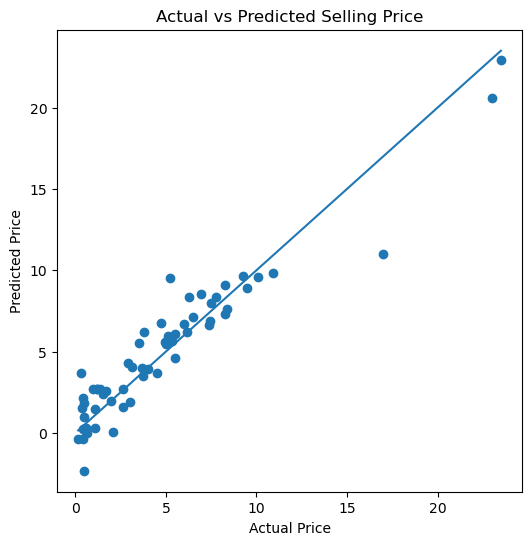

In [15]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, preds)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Selling Price")
plt.show()

In [27]:
with open("car_price_model1.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully as car_price_model1.pkl")

Model saved successfully as car_price_model1.pkl


In [31]:
import pickle
import pandas as pd

# Load saved model
with open("car_price_model1.pkl", "rb") as file:
    loaded_model = pickle.load(file)

# Example: take one row from dataset
df = pd.read_csv("car data.csv")
sample = df.drop("Selling_Price", axis=1).iloc[[0]]

# Predict
prediction = loaded_model.predict(sample)
print("Predicted Selling Price:", prediction[0])

Predicted Selling Price: 3.81302924523518


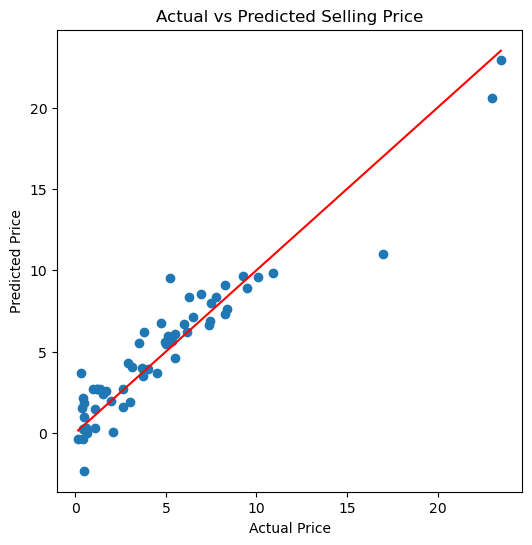

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, preds)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Selling Price")
plt.show()